In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Caminho relativo ao notebook: nada de caminho absoluto (reprodutibilidade, Ap. F §F.12).
ARQUIVO = Path("pwt110.xlsx")
assert ARQUIVO.exists(), f"nao encontrei {ARQUIVO.resolve()}"

print(f"pandas {pd.__version__} | numpy {np.__version__}")
print(f"arquivo: {ARQUIVO.resolve()}  ({ARQUIVO.stat().st_size / 1e6:.1f} MB)")

pandas 2.3.3 | numpy 2.4.0
arquivo: D:\Documents\Git\Github\Finanças 01 - MPE\Pedro\Soluções\Lista 1\pwt110.xlsx  (5.8 MB)


In [12]:
abas = pd.ExcelFile(ARQUIVO).sheet_names
print("abas:", abas)

legend = pd.read_excel(ARQUIVO, sheet_name="Legend")
pwt = pd.read_excel(ARQUIVO, sheet_name="Data")

print(f"\nData:   {pwt.shape[0]:,} linhas x {pwt.shape[1]} colunas")
print(f"Legend: {legend.shape[0]} variaveis documentadas")

abas: ['Info', 'Legend', 'Data']

Data:   13,690 linhas x 51 colunas
Legend: 66 variaveis documentadas


In [13]:
print(f"paises:  {pwt['countrycode'].nunique()}")
print(f"anos:    {int(pwt['year'].min())} a {int(pwt['year'].max())}")
print(f"painel:  {'balanceado' if pwt.groupby('countrycode').size().nunique() == 1 else 'desbalanceado'}")

pwt.head()

paises:  185
anos:    1950 a 2023
painel:  balanceado


,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,ccon,cda,cgdpe,cgdpo,cn,ck,ctfp,cwtfp,rgdpna,rconna,rdana,rnna,rkna,rtfpna,rwtfpna,labsh,irr,delta,xr,pl_con,pl_da,pl_gdpo,i_cig,i_xm,i_xr,i_outlier,i_irr,cor_exp,csh_c,csh_i,csh_g,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,ABW,Aruba,Aruban Guilder,1950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,Aruban Guilder,1951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,Aruban Guilder,1952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,Aruban Guilder,1953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,Aruban Guilder,1954,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Dicionario de variaveis: consultar antes de usar qualquer coluna.
LARGURA_DEF = 100  # definicao cortada para caber na tela


def descrever(*variaveis: str, largura: int = LARGURA_DEF) -> pd.DataFrame:
    """Definicao das variaveis pedidas, direto da aba Legend, cortada em `largura` caracteres."""
    col_nome, col_def = legend.columns[0], legend.columns[1]
    sel = legend.loc[legend[col_nome].isin(variaveis)].set_index(col_nome)
    curta = sel[col_def].map(lambda t: t if len(str(t)) <= largura else str(t)[: largura - 1] + "…")
    return curta.to_frame()


descrever("rgdpe", "rgdpo", "rgdpna", "pop", "emp", "avh", "hc", "rnna", "rkna", "rtfpna", "labsh", "delta")

,Variable definition
Variable name,
rgdpe,Expenditure-side real GDP at chained PPPs (in ...
rgdpo,Output-side real GDP at chained PPPs (in mil. ...
pop,Population (in millions)
emp,Number of persons engaged (in millions)
avh,Average annual hours worked by persons engaged
hc,"Human capital index, based on years of schooli..."
rgdpna,Real GDP at constant 2021 national prices (in ...
rnna,Capital stock at constant 2021 national prices...
rkna,Capital services at constant 2021 national pri...


In [15]:
# Crescimento medio do PIB real per capita (rgdpna / pop), por pais, de 1964 a 2014.
ANO_INI, ANO_FIM = 1960, 2014
N_ANOS = ANO_FIM - ANO_INI + 1

janela = pwt.loc[pwt["year"].between(ANO_INI, ANO_FIM), ["countrycode", "country", "year", "rgdpna", "pop"]].copy()
janela["y"] = janela["rgdpna"] / janela["pop"]  # PIB real per capita, precos nacionais constantes de 2021
janela = janela.dropna(subset=["y"]).sort_values(["countrycode", "year"])

# So paises com a serie inteira: sem isso o CAGR de cada pais mediria uma janela diferente.
cobertos = janela.groupby("countrycode")["year"].nunique().eq(N_ANOS)
janela = janela[janela["countrycode"].isin(cobertos[cobertos].index)]

crescimento = (
    janela.groupby("countrycode")
    .agg(
        pais=("country", "first"),
        y_1960=("y", "first"),
        y_2014=("y", "last"),
    )
    .assign(
        # Media geometrica = CAGR: a taxa que leva y_1960 a y_2014 em (N_ANOS - 1) periodos.
        media_geometrica=lambda d: 100 * ((d["y_2014"] / d["y_1960"]) ** (1 / (N_ANOS - 1)) - 1),
        multiplo=lambda d: d["y_2014"] / d["y_1960"],
    )
    .sort_values("media_geometrica", ascending=False)
)

print(f"{janela['countrycode'].nunique()} paises com serie completa de {ANO_INI} a {ANO_FIM} "
      f"(de {pwt['countrycode'].nunique()} no PWT)")
print("media_geometrica em % ao ano\n")

crescimento.head(10)

111 paises com serie completa de 1960 a 2014 (de 185 no PWT)
media_geometrica em % ao ano



,pais,y_1960,y_2014,media_geometrica,multiplo
countrycode,,,,,
CHN,China,462.846280,13458.758211,6.439571,29.078246
KOR,Republic of Korea,1900.704630,45934.722247,6.075553,24.167207
TWN,Taiwan,2005.478180,47380.177267,6.031020,23.625377
BWA,Botswana,1066.509701,16247.480340,5.172960,15.234255
SGP,Singapore,5761.202099,86387.644515,5.142098,14.994726
GNQ,Equatorial Guinea,2899.719625,37898.489806,4.874907,13.069708
MLT,Malta,2912.798146,35395.739712,4.733577,12.151800
THA,Thailand,1540.745541,18253.376026,4.684337,11.847106
HKG,"China, Hong Kong SAR",5455.191504,55032.896881,4.373229,10.088170


In [16]:
# Converta 'y' para 'GDPperCapita'. Os anos vem de ANO_INI/ANO_FIM: se a janela mudar, o nome muda junto.
crescimento = crescimento.rename(
    columns={
        "y_1960": f"GDPperCapita_{ANO_INI}",
        "y_2014": f"GDPperCapita_{ANO_FIM}",
        "media_geometrica": "growth",
    }
)
X_INICIAL = f"GDPperCapita_{ANO_INI}"  # use esta variavel em vez de digitar o ano
crescimento

,pais,GDPperCapita_1960,GDPperCapita_2014,growth,multiplo
countrycode,,,,,
CHN,China,462.846280,13458.758211,6.439571,29.078246
KOR,Republic of Korea,1900.704630,45934.722247,6.075553,24.167207
TWN,Taiwan,2005.478180,47380.177267,6.031020,23.625377
BWA,Botswana,1066.509701,16247.480340,5.172960,15.234255
SGP,Singapore,5761.202099,86387.644515,5.142098,14.994726
...,...,...,...,...,...
GNB,Guinea-Bissau,2719.628100,1909.654748,-0.652625,0.702175
NER,Niger,2150.357390,1411.895298,-0.776049,0.656586
MDG,Madagascar,2678.052808,1627.817532,-0.917707,0.607836


In [17]:
# Categorize os paises em regioes — por codigo ISO3, que e o indice de `crescimento`.
# Codigo em vez de nome elimina o risco de grafia ("Venezuela" != "Venezuela (Bolivarian Republic of)").
# As listas sao a regiao INTEIRA no PWT (185 paises); o cruzamento com a janela ativa e feito abaixo,
# entao mudar ANO_INI nao obriga a mexer aqui.

REGIOES_PWT = {
    "Europe": (
        "ALB AUT BEL BGR BIH BLR CHE CZE DEU DNK ESP EST FIN FRA GBR GRC HRV HUN IRL ISL ITA LTU LUX"
        " LVA MDA MKD MLT MNE NLD NOR POL PRT ROU RUS SRB SVK SVN SWE UKR"
    ),
    "Latin America": "ARG BOL BRA CHL COL CRI DOM ECU GTM HND HTI MEX NIC PAN PER PRY SLV URY VEN",
    "Africa": (
        "AGO BDI BEN BFA BWA CAF CIV CMR COD COG COM CPV DJI DZA EGY ETH GAB GHA GIN GMB GNB GNQ KEN"
        " LBR LSO MAR MDG MLI MOZ MRT MUS MWI NAM NER NGA RWA SDN SEN SLE SOM SSD STP SWZ SYC TCD TGO"
        " TUN TZA UGA ZAF ZMB ZWE"
    ),
}

# Casos de fronteira, fora por padrao — ligue conforme a definicao que a lista adotar.
INCLUIR_TRANSCONTINENTAIS = False  # CYP, TUR (e o Caucaso): "Europe" em contexto OCDE/UE, nao geografico
INCLUIR_CARIBE = False  # Caribe e Guianas: entram se a definicao for "America Latina e Caribe"

if INCLUIR_TRANSCONTINENTAIS:
    REGIOES_PWT["Europe"] += " CYP TUR ARM AZE GEO"
if INCLUIR_CARIBE:
    REGIOES_PWT["Latin America"] += " ATG BHS BLZ BRB DMA GRD GUY JAM KNA LCA SUR TTO VCT"

# So o que sobrevive a janela: quem nao tem serie completa nem chegou em `crescimento`.
regions = {r: sorted(set(cods.split()) & set(crescimento.index)) for r, cods in REGIOES_PWT.items()}

codigo_para_regiao = {cod: r for r, cods in regions.items() for cod in cods}
crescimento["regiao"] = crescimento.index.map(codigo_para_regiao)

# Quem ficou de fora e por que — sem isso, um pais some em silencio.
for regiao, cods in REGIOES_PWT.items():
    universo = set(cods.split())
    fora = sorted(universo - set(regions[regiao]))
    print(f"{regiao:<15} {len(regions[regiao]):>2}/{len(universo)} com serie {ANO_INI}-{ANO_FIM}"
          f"  | sem serie: {' '.join(fora) if fora else 'nenhum'}")

print(f"\n{crescimento['regiao'].notna().sum()} de {len(crescimento)} paises classificados"
      f" ({crescimento['regiao'].isna().sum()} em Asia, Oceania, America do Norte e Caribe)\n")
crescimento["regiao"].value_counts(dropna=False)

Europe          20/39 com serie 1960-2014  | sem serie: ALB BGR BIH BLR CZE EST HRV HUN LTU LVA MDA MKD MNE POL RUS SRB SVK SVN UKR
Latin America   19/19 com serie 1960-2014  | sem serie: nenhum
Africa          43/52 com serie 1960-2014  | sem serie: AGO DJI LBR SDN SLE SOM SSD STP SWZ

82 de 111 paises classificados (29 em Asia, Oceania, America do Norte e Caribe)



regiao
Africa           43
NaN              29
Europe           20
Latin America    19
Name: count, dtype: int64

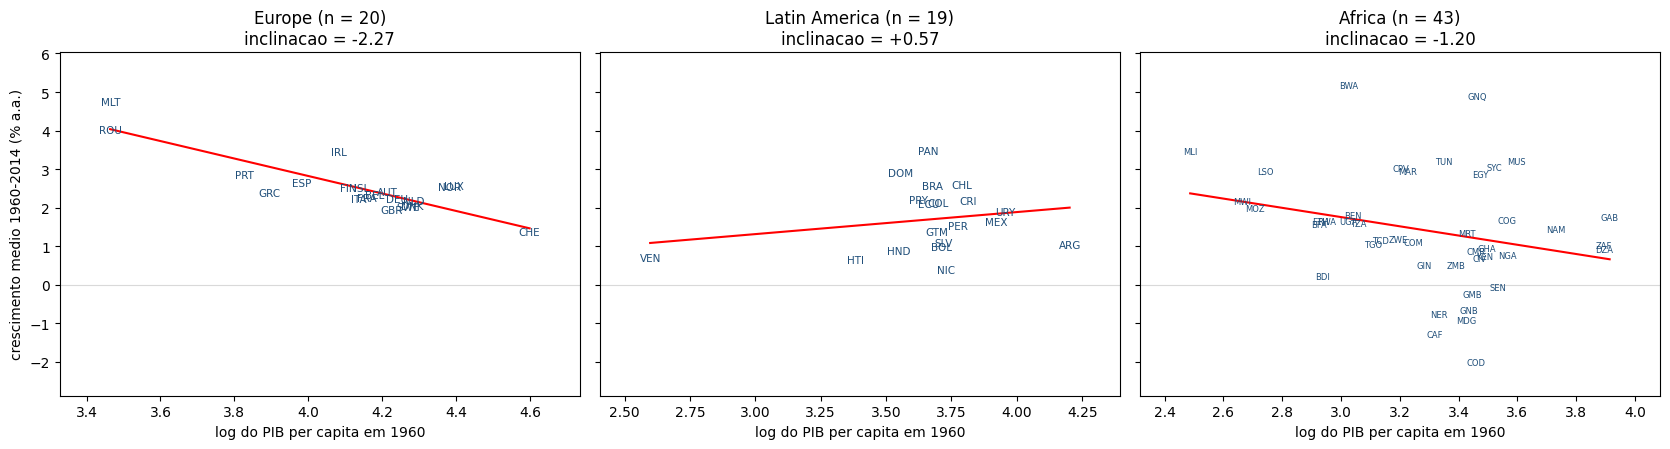

In [18]:
# Convergencia: crescimento medio contra o nivel inicial de renda, uma regiao por painel.
LOG_X = True  # eixo x em log e a especificacao padrao de beta-convergencia (a inclinacao vira beta)

fig, axes = plt.subplots(1, len(regions), figsize=(5.6 * len(regions), 4.6), sharey=True)
axes = np.atleast_1d(axes)

for ax, regiao in zip(axes, regions):
    d = crescimento[crescimento["regiao"] == regiao]
    if d.empty:  # nunca mais um polyfit em vetor vazio
        ax.set_title(f"{regiao}: sem paises na amostra")
        continue

    x = np.log(d[X_INICIAL]) / np.log(10) if LOG_X else d[X_INICIAL]
    y = d["growth"]

    # O ponto e o proprio countrycode. O scatter fica invisivel (s=0) so para o
    # autoscale enxergar os dados: ax.annotate sozinho nao move os limites do eixo.
    ax.scatter(x, y, s=0)
    corpo = 7.5 if len(d) <= 20 else 6.0  # Africa tem ~50 rotulos; o texto tem que encolher
    for codigo, xi, yi in zip(d.index, x, y):
        ax.annotate(codigo, (xi, yi), ha="center", va="center", fontsize=corpo, color="#1f4e79")
    ax.margins(0.12)  # folga para os rotulos das bordas nao saírem cortados

    b, a = np.polyfit(x, y, 1)  # inclinacao, intercepto
    xs = np.linspace(x.min(), x.max(), 10)
    ax.plot(xs, a + b * xs, "r-", zorder=0)

    ax.axhline(0, color="0.85", lw=0.8, zorder=0)
    ax.set_title(f"{regiao} (n = {len(d)})\ninclinacao = {b:+.2f}")
    ax.set_xlabel(f"log do PIB per capita em {ANO_INI}" if LOG_X else f"PIB per capita em {ANO_INI}")

axes[0].set_ylabel(f"crescimento medio {ANO_INI}-{ANO_FIM} (% a.a.)")
fig.tight_layout()
plt.show()